# Customer Lifetime Value (CLV) Prediction

## Business Problem

Customer Lifetime Value (CLV) estimates the future revenue expected from each customer. Accurate CLV prediction enables businesses to prioritize high-value customers, optimize marketing budgets, improve customer retention strategies, and maximize long-term profitability.

## Objective

Develop a machine learning regression pipeline that predicts future customer revenue using historical purchasing behavior and customer personas. The predicted CLV will later be combined with churn probability to estimate Revenue-at-Risk.

In [22]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import joblib

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

# Regression Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

In [23]:
customer_df = pd.read_csv(
    "../data/processed/customer_personas.csv"
)

future_df = pd.read_csv(
    "../data/processed/future_transactions.csv"
)

customer_df.head()

,CustomerID,Recency,Frequency,Monetary,Average_Order_Value,R_Score,F_Score,M_Score,RFM_Score,Segment,Persona_ID,Customer_Persona
0,12346.0,325,1,77183.60,77183.60,1,1,5,115,Lost Customers,1,Active Customers
1,12347.0,129,5,2790.86,558.17,4,4,5,445,Champions,2,VIP Customers
2,12348.0,248,3,1487.24,495.75,2,4,4,244,At Risk,0,Dormant Customers
3,12350.0,309,1,334.40,334.40,1,1,2,112,Lost Customers,0,Dormant Customers
4,12352.0,261,5,1561.81,312.36,2,4,4,244,At Risk,0,Dormant Customers


In [24]:
customer_df.shape

(3365, 12)

In [25]:
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3365 entries, 0 to 3364
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           3365 non-null   float64
 1   Recency              3365 non-null   int64  
 2   Frequency            3365 non-null   int64  
 3   Monetary             3365 non-null   float64
 4   Average_Order_Value  3365 non-null   float64
 5   R_Score              3365 non-null   int64  
 6   F_Score              3365 non-null   int64  
 7   M_Score              3365 non-null   int64  
 8   RFM_Score            3365 non-null   int64  
 9   Segment              3365 non-null   str    
 10  Persona_ID           3365 non-null   int64  
 11  Customer_Persona     3365 non-null   str    
dtypes: float64(3), int64(7), str(2)
memory usage: 406.6 KB


In [26]:
customer_df.describe()

,CustomerID,Recency,Frequency,Monetary,Average_Order_Value,R_Score,F_Score,M_Score,RFM_Score,Persona_ID
count,3365.000000,3365.000000,3365.000000,3365.000000,3365.000000,3365.000000,3365.000000,3365.000000,3365.000000,3365.000000
mean,15274.942942,184.960178,3.529866,1613.288458,397.421001,3.015453,3.000000,3.000000,334.545319,1.282318
std,1726.349698,79.863689,5.780679,6149.992648,1423.570904,1.415390,1.414424,1.414424,150.393157,0.955583
min,12346.000000,91.000000,1.000000,2.900000,2.900000,1.000000,1.000000,1.000000,111.000000,0.000000
25%,13784.000000,116.000000,1.000000,263.920000,168.310000,2.000000,2.000000,2.000000,215.000000,0.000000
50%,15232.000000,164.000000,2.000000,563.630000,283.030000,3.000000,3.000000,3.000000,333.000000,2.000000
75%,16766.000000,241.000000,4.000000,1392.840000,412.650000,4.000000,4.000000,4.000000,454.000000,2.000000
max,18287.000000,373.000000,131.000000,178302.620000,77183.600000,5.000000,5.000000,5.000000,555.000000,2.000000


In [27]:
customer_df.isnull().sum()

CustomerID             0
Recency                0
Frequency              0
Monetary               0
Average_Order_Value    0
R_Score                0
F_Score                0
M_Score                0
RFM_Score              0
Segment                0
Persona_ID             0
Customer_Persona       0
dtype: int64

In [28]:
future_clv = (

    future_df

    .groupby("CustomerID")["Revenue"]

    .sum()

)

In [29]:
customer_df = customer_df.merge(

    future_clv.rename("Future_CLV"),

    on="CustomerID",

    how="left"

)

In [30]:
customer_df["Future_CLV"] = (

    customer_df["Future_CLV"]

    .fillna(0)

)

In [31]:
customer_df.head()

,CustomerID,Recency,Frequency,Monetary,Average_Order_Value,R_Score,F_Score,M_Score,RFM_Score,Segment,Persona_ID,Customer_Persona,Future_CLV
0,12346.0,325,1,77183.60,77183.60,1,1,5,115,Lost Customers,1,Active Customers,0.00
1,12347.0,129,5,2790.86,558.17,4,4,5,445,Champions,2,VIP Customers,1519.14
2,12348.0,248,3,1487.24,495.75,2,4,4,244,At Risk,0,Dormant Customers,310.00
3,12350.0,309,1,334.40,334.40,1,1,2,112,Lost Customers,0,Dormant Customers,0.00
4,12352.0,261,5,1561.81,312.36,2,4,4,244,At Risk,0,Dormant Customers,944.23


In [32]:
customer_df["Future_CLV"].describe()

count      3365.000000
mean        848.123436
std        5012.073351
min           0.000000
25%           0.000000
50%         173.810000
75%         690.110000
max      168469.600000
Name: Future_CLV, dtype: float64

In [33]:
customer_df["Future_CLV"].isnull().sum()

np.int64(0)

In [34]:
print(
    "Zero Future CLV:",
    (customer_df["Future_CLV"] == 0).sum()
)

print(
    "Positive Future CLV:",
    (customer_df["Future_CLV"] > 0).sum()
)

print(
    "Percentage:",
    (customer_df["Future_CLV"] == 0).mean()*100
)

Zero Future CLV: 1445
Positive Future CLV: 1920
Percentage: 42.94205052005943


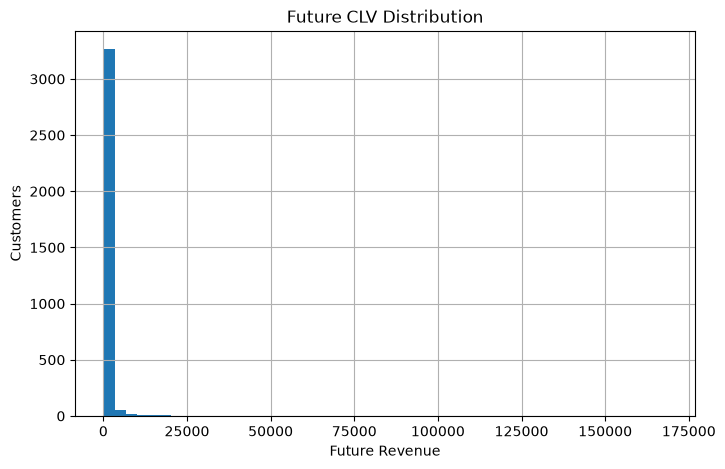

In [35]:
plt.figure(figsize=(8,5))

customer_df["Future_CLV"].hist(
    bins=50
)

plt.title("Future CLV Distribution")

plt.xlabel("Future Revenue")

plt.ylabel("Customers")

plt.show()

In [36]:
customer_df["Log_Future_CLV"] = np.log1p(
    customer_df["Future_CLV"]
)

In [37]:
customer_df[
    [
        "Future_CLV",
        "Log_Future_CLV"
    ]
].head()

,Future_CLV,Log_Future_CLV
0,0.00,0.000000
1,1519.14,7.326558
2,310.00,5.739793
3,0.00,0.000000
4,944.23,6.851428


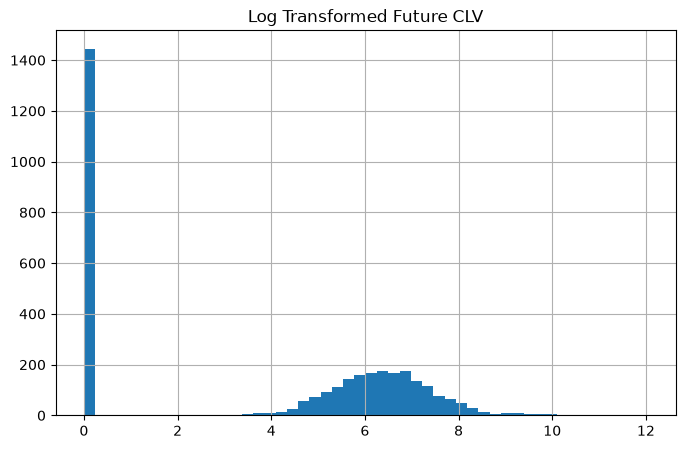

In [38]:
plt.figure(figsize=(8,5))

customer_df["Log_Future_CLV"].hist(
    bins=50
)

plt.title("Log Transformed Future CLV")

plt.show()

In [39]:
features = [

    "Recency",

    "Frequency",

    "Monetary",

    "Average_Order_Value",

    "Customer_Persona"

]

X = customer_df[features]

y = customer_df["Log_Future_CLV"]

In [40]:
X.head()

,Recency,Frequency,Monetary,Average_Order_Value,Customer_Persona
0,325,1,77183.60,77183.60,Active Customers
1,129,5,2790.86,558.17,VIP Customers
2,248,3,1487.24,495.75,Dormant Customers
3,309,1,334.40,334.40,Dormant Customers
4,261,5,1561.81,312.36,Dormant Customers


In [41]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [42]:
print(X_train.shape)

print(X_test.shape)

(2692, 5)
(673, 5)


In [43]:
numeric_features = [

    "Recency",

    "Frequency",

    "Monetary",

    "Average_Order_Value"

]

categorical_features = [

    "Customer_Persona"

]

In [44]:
preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            StandardScaler(),

            numeric_features

        ),

        (

            "cat",

            OneHotEncoder(
                handle_unknown="ignore"
            ),

            categorical_features

        )

    ]

)

In [49]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Ridge":
        Ridge(),

    "Lasso":
        Lasso(),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        ),

    "XGBoost":
        XGBRegressor(
            random_state=42,
            objective="reg:squarederror"
        )


    

}

In [50]:
cv_results = []
from sklearn.ensemble import ExtraTreesRegressor

for model_name, model in models.items():

    pipeline = Pipeline([

        ("preprocessor", preprocessor),

        ("model", model)

    ])

    scores = cross_val_score(

        pipeline,

        X_train,

        y_train,

        cv=5,

        scoring="r2",

        n_jobs=-1

    )

    cv_results.append({

        "Model": model_name,

        "Mean_R2": scores.mean(),

        "Std": scores.std()

    })

    print("="*60)

    print(model_name)

    print(scores)

    print(f"Average R² : {scores.mean():.4f}")

Linear Regression
[0.18465386 0.1528345  0.20920107 0.21286672 0.21287983]
Average R² : 0.1945
Ridge
[0.18560285 0.15189062 0.20837763 0.21497501 0.21298073]
Average R² : 0.1948
Lasso
[0.05003432 0.04688085 0.04811703 0.05689641 0.02931945]
Average R² : 0.0462
Decision Tree
[-0.48684754 -0.52364194 -0.50802121 -0.48108999 -0.47988205]
Average R² : -0.4959
Random Forest
[0.14781777 0.10835973 0.16289387 0.14734782 0.16937459]
Average R² : 0.1472
Gradient Boosting
[0.22316227 0.22411545 0.23782611 0.28186731 0.26499   ]
Average R² : 0.2464
XGBoost
[0.04422489 0.04626119 0.04241797 0.09998132 0.07566263]
Average R² : 0.0617


In [51]:
cv_results = pd.DataFrame(cv_results)

cv_results.sort_values(
    by="Mean_R2",
    ascending=False,
    inplace=True
)

cv_results

,Model,Mean_R2,Std
5,Gradient Boosting,0.246392,0.023296
1,Ridge,0.194765,0.023865
0,Linear Regression,0.194487,0.023342
4,Random Forest,0.147159,0.021199
6,XGBoost,0.061710,0.022698
2,Lasso,0.046250,0.009145
3,Decision Tree,-0.495897,0.017172


In [52]:
param_grids = {

    "Linear Regression": {},

    "Ridge": {

        "model__alpha": [0.01, 0.1, 1, 10, 100]

    },

    "Lasso": {

        "model__alpha": [0.001, 0.01, 0.1, 1]

    },

    "Decision Tree": {

        "model__criterion": [
            "squared_error",
            "friedman_mse"
        ],

        "model__max_depth": [
            3,5,10,20,None
        ],

        "model__min_samples_split": [
            2,5,10
        ],

        "model__min_samples_leaf": [
            1,2,4
        ]

    },

    "Random Forest": {

        "model__n_estimators":[
            100,200,300,500
        ],

        "model__max_depth":[
            5,10,20,None
        ],

        "model__min_samples_split":[
            2,5,10
        ],

        "model__min_samples_leaf":[
            1,2,4
        ]

    },

    "Gradient Boosting": {

        "model__n_estimators":[
            100,200,300
        ],

        "model__learning_rate":[
            0.01,0.05,0.1
        ],

        "model__max_depth":[
            2,3,5
        ]

    },

    "XGBoost": {

        "model__n_estimators":[
            100,200,300
        ],

        "model__learning_rate":[
            0.01,0.05,0.1
        ],

        "model__max_depth":[
            3,5,7
        ],

        "model__subsample":[
            0.8,1.0
        ],

        "model__colsample_bytree":[
            0.8,1.0
        ]

    }

}

In [53]:
search_strategy = {

    "Linear Regression":"none",

    "Ridge":"grid",

    "Lasso":"grid",

    "Decision Tree":"grid",

    "Random Forest":"random",

    "Gradient Boosting":"random",

    "XGBoost":"random"

}

In [54]:
from sklearn.model_selection import (

    GridSearchCV,

    RandomizedSearchCV

)

In [55]:
def tune_model(

    model_name,

    model,

    params,

    preprocessor,

    X_train,

    y_train

):

    pipeline = Pipeline(

        [

            ("preprocessor",preprocessor),

            ("model",model)

        ]

    )

    if search_strategy[model_name] == "none":

        pipeline.fit(

            X_train,

            y_train

        )

        return pipeline,None

    elif search_strategy[model_name] == "grid":

        search = GridSearchCV(

            estimator=pipeline,

            param_grid=params,

            cv=5,

            scoring="r2",

            n_jobs=-1

        )

    else:

        search = RandomizedSearchCV(

            estimator=pipeline,

            param_distributions=params,

            n_iter=20,

            cv=5,

            scoring="r2",

            random_state=42,

            n_jobs=-1

        )

    search.fit(

        X_train,

        y_train

    )

    return search.best_estimator_,search

In [56]:
best_models = {}

tuning_results = []

In [57]:
for model_name,model in models.items():

    print("="*70)

    print(f"Tuning {model_name}")

    best_pipeline,search = tune_model(

        model_name=model_name,

        model=model,

        params=param_grids[model_name],

        preprocessor=preprocessor,

        X_train=X_train,

        y_train=y_train

    )

    best_models[model_name]=best_pipeline

    if search is None:

        tuning_results.append({

            "Model":model_name,

            "Best_R2":cross_val_score(

                best_pipeline,

                X_train,

                y_train,

                cv=5,

                scoring="r2"

            ).mean(),

            "Best_Params":"Default"

        })

    else:

        tuning_results.append({

            "Model":model_name,

            "Best_R2":search.best_score_,

            "Best_Params":search.best_params_

        })

        print(

            search.best_params_

        )

        print(

            "Best R²:",

            round(search.best_score_,4)

        )

Tuning Linear Regression
Tuning Ridge
{'model__alpha': 1}
Best R²: 0.1948
Tuning Lasso
{'model__alpha': 0.001}
Best R²: 0.1947
Tuning Decision Tree
{'model__criterion': 'squared_error', 'model__max_depth': 3, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
Best R²: 0.2281
Tuning Random Forest
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 5}
Best R²: 0.2587
Tuning Gradient Boosting
{'model__n_estimators': 100, 'model__max_depth': 2, 'model__learning_rate': 0.05}
Best R²: 0.2649
Tuning XGBoost
{'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}
Best R²: 0.2629


In [58]:
tuning_results = pd.DataFrame(

    tuning_results

)

tuning_results.sort_values(

    by="Best_R2",

    ascending=False,

    inplace=True

)

tuning_results

,Model,Best_R2,Best_Params
5,Gradient Boosting,0.264908,"{'model__n_estimators': 100, 'model__max_depth..."
6,XGBoost,0.262916,"{'model__subsample': 0.8, 'model__n_estimators..."
4,Random Forest,0.258678,"{'model__n_estimators': 300, 'model__min_sampl..."
3,Decision Tree,0.228107,"{'model__criterion': 'squared_error', 'model__..."
1,Ridge,0.194765,{'model__alpha': 1}
2,Lasso,0.194701,{'model__alpha': 0.001}
0,Linear Regression,0.194487,Default


In [59]:
best_model_name = tuning_results.iloc[0]["Model"]

print(best_model_name)

Gradient Boosting


In [60]:
best_pipeline = best_models[best_model_name]

In [64]:
y_pred_log = best_pipeline.predict(X_test)

y_pred = np.expm1(y_pred_log)

y_test_original = np.expm1(y_test)

In [65]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [67]:
def evaluate_model(model, X_test, y_test):

    y_pred_log = model.predict(X_test)

    y_pred = np.expm1(y_pred_log)

    y_true = np.expm1(y_test)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    print("="*70)
    print("Model Evaluation")
    print("="*70)

    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")

    return {

        "MAE":mae,

        "RMSE":rmse,

        "R2":r2

    }

In [68]:
metrics = evaluate_model(

    best_pipeline,

    X_test,

    y_test

)

Model Evaluation
MAE  : 821.53
RMSE : 5541.76
R²   : 0.1616


In [70]:
comparison = []

for model_name, model in best_models.items():

    y_pred_log = model.predict(X_test)

    y_pred = np.expm1(y_pred_log)

    y_true = np.expm1(y_test)

    comparison.append({

        "Model": model_name,

        "MAE": mean_absolute_error(y_true, y_pred),

        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),

        "R2": r2_score(y_true, y_pred)

    })

In [71]:
comparison_df = pd.DataFrame(comparison)

comparison_df.sort_values(
    by="R2",
    ascending=False,
    inplace=True
)

comparison_df

,Model,MAE,RMSE,R2
4,Random Forest,7.366621e+02,4.563059e+03,4.316109e-01
5,Gradient Boosting,8.215300e+02,5.541755e+03,1.616445e-01
6,XGBoost,8.324132e+02,5.645785e+03,1.298739e-01
3,Decision Tree,8.837980e+02,5.901188e+03,4.936801e-02
0,Linear Regression,7.230492e+07,1.867575e+09,-9.521151e+10
2,Lasso,7.622125e+07,1.971377e+09,-1.060896e+11
1,Ridge,8.165969e+07,2.113841e+09,-1.219770e+11


In [72]:
best_model_name = comparison_df.iloc[0]["Model"]

print(best_model_name)

Random Forest


In [73]:
best_pipeline = best_models[best_model_name]

In [74]:
import joblib

joblib.dump(
    best_pipeline,
    "../models/clv_prediction_pipeline.pkl"
)

print("Pipeline Saved Successfully")

Pipeline Saved Successfully


In [75]:
loaded_pipeline = joblib.load(
    "../models/clv_prediction_pipeline.pkl"
)

loaded_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Recency','Frequency','Monetary','Average_Order_Value','Customer_Persona']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colum

In [76]:
X_all = customer_df[features]

customer_df["Predicted_CLV"] = np.expm1(
    best_pipeline.predict(X_all)
)

In [77]:
customer_df["Predicted_CLV"] = (
    customer_df["Predicted_CLV"]
    .clip(lower=0)
)

In [78]:
customer_df[

    [

        "CustomerID",

        "Future_CLV",

        "Predicted_CLV"

    ]

].head()

,CustomerID,Future_CLV,Predicted_CLV
0,12346.0,0.00,19.416396
1,12347.0,1519.14,393.605693
2,12348.0,310.00,55.950604
3,12350.0,0.00,4.608591
4,12352.0,944.23,153.868665


In [79]:
customer_df["Predicted_CLV"].describe()

count     3365.000000
mean       303.035862
std       1481.248640
min          1.622230
25%          8.148539
50%         24.286254
75%        124.401234
max      25890.416230
Name: Predicted_CLV, dtype: float64

In [80]:
customer_df.to_csv(

    "../data/processed/customer_clv_predictions.csv",

    index=False

)

Random Forest achieved the best predictive performance on the unseen test dataset and was selected as the final production model for Customer Lifetime Value prediction.